# 01. Titanic ベースライン

流れ: 環境準備 → データ取得 → EDA → 前処理 → ベースラインモデル → 提出ファイル作成

事前準備:
- Kaggle の Titanic コンペでルールに同意（Join）しておく
- Colab の「シークレット」に `KAGGLE_API_TOKEN` を登録し、ノートブックからのアクセスをオンにする

## 1. 環境準備（Kaggle 認証）

In [1]:
import os
from google.colab import userdata

# Kaggle 認証（キーはコードに直書きしない）
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

# データは Colab 内の一時領域に置く（Drive の許可は不要。Titanic は小さいので毎回取得で十分）
DATA_DIR = '/content/data/titanic'
OUT_DIR = '/content/outputs/titanic'
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

## 2. データのダウンロード（Colab 内の一時領域へ。セッションごとに1回）

In [2]:
if not os.path.exists(f'{DATA_DIR}/train.csv'):
    !pip install -q -U kaggle
    !kaggle competitions download -c titanic -p {DATA_DIR}
    !unzip -o {DATA_DIR}/titanic.zip -d {DATA_DIR}
else:
    print('データは取得済みです。ダウンロードをスキップします。')

!ls -la {DATA_DIR}

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 2.9 MB/s eta 0:00:00
100% 34.1k/34.1k [00:00<00:00, 54.4MB/s]

Archive:  /content/data/titanic/titanic.zip
  inflating: /content/data/titanic/gender_submission.csv  
  inflating: /content/data/titanic/test.csv  
  inflating: /content/data/titanic/train.csv  
total 136
drwxr-xr-x 2 root root  4096 Oct  4 06:52 .
drwxr-xr-x 3 root root  4096 Oct  4 06:52 ..
-rw-r--r-- 1 root root  3258 Dec 11  2019 gender_submission.csv
-rw-r--r-- 1 root root 28629 Dec 11  2019 test.csv
-rw-r--r-- 1 root root 34877 Dec 11  2019 titanic.zip
-rw-r--r-- 1 root root 61194 Dec 11  2019 train.csv


## 3. データの読み込みと基本確認

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train = pd.read_csv(f'{DATA_DIR}/train.csv')
test = pd.read_csv(f'{DATA_DIR}/test.csv')

print(train.shape, test.shape)
train.head()

(891, 12) (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
train.info()
print()
print('欠損数:')
print(train.isnull().sum())
train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

欠損数:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 4. EDA（探索的データ分析）

考えてみる問い: どの属性で生存率が大きく違うか？ 欠損の多い列はどう扱うか？

In [11]:
!apt-get -qq install -y fonts-noto-cjk > /dev/null

import glob
from matplotlib import font_manager as fm

for f in glob.glob('/usr/share/fonts/opentype/noto/NotoSansCJK-*.ttc'):
    fm.fontManager.addfont(f)
plt.rcParams['font.family'] = 'Noto Sans CJK JP'
plt.rcParams['axes.unicode_minus'] = False

print('日本語フォント設定:', 'Noto Sans CJK JP' in {f.name for f in fm.fontManager.ttflist})

日本語フォント設定: True


全体の生存率: 0.384


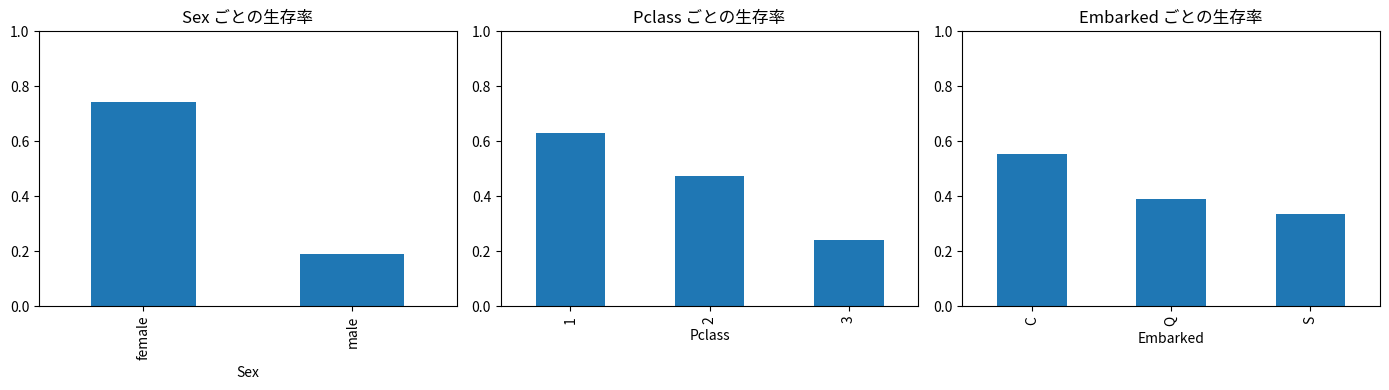

In [12]:
print('全体の生存率:', round(train['Survived'].mean(), 3))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['Sex', 'Pclass', 'Embarked']):
    train.groupby(col)['Survived'].mean().plot(kind='bar', ax=ax)
    ax.set_title(f'{col} ごとの生存率')
    ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

Pclass         1         2         3
Sex                                 
female  0.968085  0.921053  0.500000
male    0.368852  0.157407  0.135447


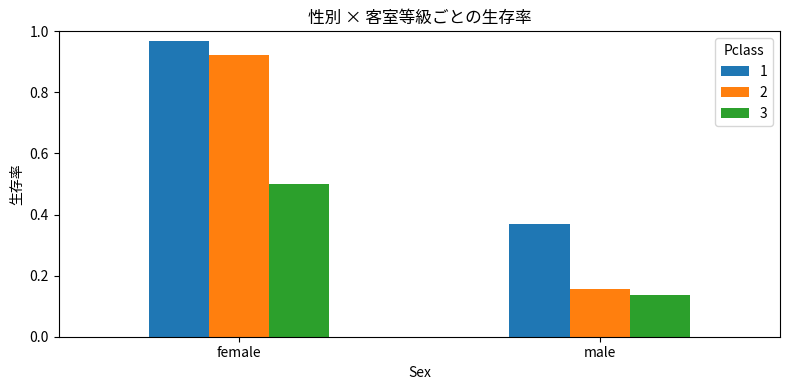

In [14]:
rate = train.groupby(['Sex', 'Pclass'])['Survived'].mean().unstack()
print(rate)

fig, ax = plt.subplots(figsize=(8, 4))
rate.plot(kind='bar', ax=ax)
ax.set_title('性別 × 客室等級ごとの生存率')
ax.set_ylabel('生存率')
ax.set_ylim(0, 1)
ax.legend(title='Pclass')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

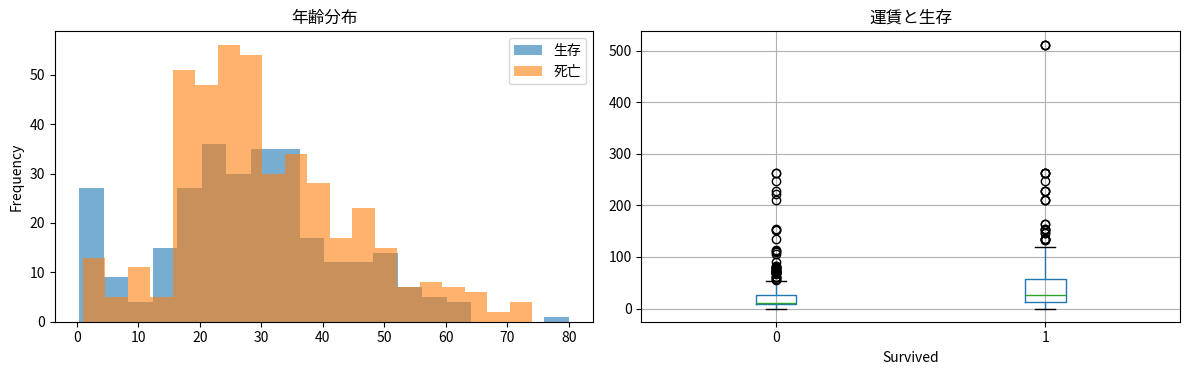

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train.loc[train['Survived'] == 1, 'Age'].plot(kind='hist', bins=20, alpha=0.6, ax=axes[0], label='生存')
train.loc[train['Survived'] == 0, 'Age'].plot(kind='hist', bins=20, alpha=0.6, ax=axes[0], label='死亡')
axes[0].set_title('年齢分布')
axes[0].legend()

train.boxplot(column='Fare', by='Survived', ax=axes[1])
axes[1].set_title('運賃と生存')
plt.suptitle('')
plt.tight_layout()
plt.show()

## 5. 前処理と特徴量

まずは最小限のベースラインを作る。特徴量の追加は次の演習で行う。

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_cols = ['Age', 'SibSp', 'Parch', 'Fare']
cat_cols = ['Pclass', 'Sex', 'Embarked']

preprocess = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]), num_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ]), cat_cols),
])

X = train[num_cols + cat_cols]
y = train['Survived']
X_test = test[num_cols + cat_cols]

## 6. ベースラインモデルと交差検証

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

models = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'RandomForest': RandomForestClassifier(n_estimators=300, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    pipe = Pipeline([('prep', preprocess), ('model', model)])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')
    print(f'{name}: 平均 {scores.mean():.4f} (標準偏差 {scores.std():.4f})')

LogisticRegression: 平均 0.7969 (標準偏差 0.0146)
RandomForest: 平均 0.8137 (標準偏差 0.0233)


## 7. 提出ファイルの作成（まず Colab 内に保存）

In [9]:
best = Pipeline([('prep', preprocess), ('model', models['RandomForest'])])
best.fit(X, y)

submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': best.predict(X_test),
})
submission.to_csv(f'{OUT_DIR}/submission_baseline.csv', index=False)
submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,1
4,896,0


## 8. Drive に保存（ここで初めて Drive の許可が求められる）

Colab 内のファイルはセッション終了で消えるので、残したい成果物だけ Drive にコピーする。

In [10]:
from google.colab import drive
import shutil

drive.mount('/content/drive')

DRIVE_OUT = '/content/drive/MyDrive/kaggle-exercise/outputs/titanic'
os.makedirs(DRIVE_OUT, exist_ok=True)
shutil.copy(f'{OUT_DIR}/submission_baseline.csv', DRIVE_OUT)
print('保存しました:', DRIVE_OUT)

Mounted at /content/drive
保存しました: /content/drive/MyDrive/kaggle-exercise/outputs/titanic


## 次のステップ

- 提出ファイルを Kaggle にアップロードしてスコアを確認する
- `Name` から敬称（Mr, Mrs, Miss など）を抽出する
- `SibSp + Parch + 1` で家族人数を作る
- `Cabin` の頭文字や欠損フラグを使う
- 特徴量を変えるたびに交差検証スコアを記録する